# Merge Dynamic Events with Tracking Data

This notebook shows how to align dynamic events with tracking data for a given match and player, using `frame_start` / `frame_end` in the events CSV. It follows the approach from `opendata/resources/Tutorials/Merging_Dynamic_Events_and_Tracking_Data_Tutorial.ipynb`. Adjust the paths as needed for your local files.



In [97]:
import pandas as pd
from pathlib import Path

# Display options
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)



In [98]:
# --- Configuration ---
MATCH_ID = 1886347

ROOT = Path.cwd()
DATA_ROOT = ROOT.parent / "opendata" / "data" / "matches"

events_file = DATA_ROOT / str(MATCH_ID) / f"{MATCH_ID}_dynamic_events.csv"
tracking_file = DATA_ROOT / str(MATCH_ID) / f"{MATCH_ID}_tracking_extrapolated.jsonl"  # from opendata
tracking_data_github_url = (
    f"https://media.githubusercontent.com/media/SkillCorner/opendata/741bdb798b0c1835057e3fa77244c1571a00e4aa/data/matches/{MATCH_ID}/{MATCH_ID}_tracking_extrapolated.jsonl"
)

print(f"Events file: {events_file}")
print(f"Events exists: {events_file.exists()}")
print(f"Tracking file: {tracking_file}")
print(f"Tracking exists: {tracking_file.exists()}")
print(f"Tracking URL fallback: {tracking_data_github_url}")


Events file: /Users/arvid/development/personal/analytics_cup/opendata/data/matches/1886347/1886347_dynamic_events.csv
Events exists: True
Tracking file: /Users/arvid/development/personal/analytics_cup/opendata/data/matches/1886347/1886347_tracking_extrapolated.jsonl
Tracking exists: True
Tracking URL fallback: https://media.githubusercontent.com/media/SkillCorner/opendata/741bdb798b0c1835057e3fa77244c1571a00e4aa/data/matches/1886347/1886347_tracking_extrapolated.jsonl


In [99]:
# --- Load data ---
if not events_file.exists():
    raise FileNotFoundError(f"Events file not found: {events_file}")

events_df = pd.read_csv(events_file)
print(f"Loaded events: {events_df.shape}")

tracking_df = pd.DataFrame()

# Try local file first
raw = pd.DataFrame()
if tracking_file.exists():
    source = "local"
    raw_source = tracking_file
    if tracking_file.suffix == ".jsonl":
        # detect git-lfs pointer
        first_bytes = tracking_file.read_text(errors="ignore")[:200]
        is_pointer = "git-lfs" in first_bytes or "oid sha" in first_bytes
        if is_pointer:
            print("Local tracking file is a git-lfs pointer; using URL fallback")
            source = "github"
            raw_source = tracking_data_github_url
        else:
            try:
                raw = pd.read_json(tracking_file, lines=True)
            except ValueError as e:
                print(f"Failed to read tracking jsonl: {e}. Is the file empty or compressed?")
                raw = pd.DataFrame()
    if source == "local" and raw.empty and tracking_file.suffix != ".jsonl":
        try:
            raw = pd.read_csv(tracking_file)
        except Exception as e:
            print(f"Failed to read tracking csv: {e}")
else:
    source = "github"
    raw_source = tracking_data_github_url

# Fallback: load from GitHub URL (as in the tutorial) if we still have nothing
if source == "github" and raw.empty:
    try:
        raw = pd.read_json(tracking_data_github_url, lines=True)
    except ValueError as e:
        print(f"Failed to read tracking from URL: {e}")
        raw = pd.DataFrame()

# Flatten tracking if we have raw data
if not raw.empty:
    if "player_data" in raw.columns:
        raw_df = pd.json_normalize(
            raw.to_dict("records"),
            "player_data",
            ["frame", "timestamp", "period", "possession", "ball_data"],
        )
        raw_df["possession_player_id"] = raw_df["possession"].apply(lambda x: x.get("player_id"))
        raw_df["possession_group"] = raw_df["possession"].apply(lambda x: x.get("group"))
        raw_df[["ball_x", "ball_y", "ball_z", "is_detected_ball"]] = pd.json_normalize(
            raw_df.ball_data
        )
        raw_df = raw_df.drop(columns=["possession", "ball_data"], errors="ignore")
        raw_df["match_id"] = MATCH_ID
        tracking_df = raw_df.copy()
    else:
        tracking_df = raw.copy()
    print(f"Loaded tracking from {source}: {tracking_df.shape} ({raw_source})")
else:
    print("Tracking file not found or empty. Update `tracking_file` or check URL.")

# Preview key columns
print("\nEvents columns (sample):", events_df.columns[:20].tolist())
if not tracking_df.empty:
    print("Tracking columns (sample):", tracking_df.columns[:20].tolist())



Loaded events: (5079, 294)
Local tracking file is a git-lfs pointer; using URL fallback
Loaded tracking from github: (956076, 14) (https://media.githubusercontent.com/media/SkillCorner/opendata/741bdb798b0c1835057e3fa77244c1571a00e4aa/data/matches/1886347/1886347_tracking_extrapolated.jsonl)

Events columns (sample): ['event_id', 'index', 'match_id', 'frame_start', 'frame_end', 'frame_physical_start', 'time_start', 'time_end', 'minute_start', 'second_start', 'duration', 'period', 'attacking_side_id', 'attacking_side', 'event_type_id', 'event_type', 'event_subtype_id', 'event_subtype', 'player_id', 'player_name']
Tracking columns (sample): ['x', 'y', 'player_id', 'is_detected', 'frame', 'timestamp', 'period', 'possession_player_id', 'possession_group', 'ball_x', 'ball_y', 'ball_z', 'is_detected_ball', 'match_id']


In [100]:
# --- Helper functions ---

def parse_time_to_seconds(value):
    """Parse time strings like MM:SS.s or HH:MM:SS into total seconds.
    If already numeric, return float(value).
    """
    if pd.isna(value):
        return float("nan")
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        parts = value.split(":")
        try:
            if len(parts) == 2:  # MM:SS.s
                minutes = float(parts[0])
                seconds = float(parts[1])
                return minutes * 60 + seconds
            if len(parts) == 3:  # HH:MM:SS
                hours = float(parts[0])
                minutes = float(parts[1])
                seconds = float(parts[2])
                return hours * 3600 + minutes * 60 + seconds
        except ValueError:
            pass
    raise ValueError(f"Unrecognized time format: {value}")


def filter_events(events: pd.DataFrame, player_id=None, event_types=None):
    df = events.copy()
    if player_id is not None and "player_id" in df.columns:
        df = df[df["player_id"] == player_id]
    if event_types is not None and "event_type" in df.columns:
        df = df[df["event_type"].isin(event_types)]
    return df


def get_tracking_for_event(event_row: pd.Series, tracking: pd.DataFrame,
                           player_id=None, frame_col="frame"):
    """Return tracking rows within [frame_start, frame_end] for the given event.

    Assumes tracking has a frame index column (default: `frame`).
    If player_id is provided, further filters tracking to that player.
    """
    if tracking.empty:
        return tracking
    if frame_col not in tracking.columns:
        raise KeyError(f"Tracking missing frame column '{frame_col}'")

    f_start = event_row.get("frame_start")
    f_end = event_row.get("frame_end")
    if pd.isna(f_start) or pd.isna(f_end):
        return tracking.iloc[0:0]

    mask = (tracking[frame_col] >= f_start) & (tracking[frame_col] <= f_end)
    sliced = tracking.loc[mask]
    if player_id is not None and "player_id" in tracking.columns:
        sliced = sliced[sliced["player_id"] == player_id]
    return sliced



In [101]:
# --- Example: select a player and fetch tracking for a specific event ---

# Pick a player from the events
player_id = events_df["player_id"].dropna().astype(int).iloc[0]
print(f"Using player_id: {player_id}")

# Filter to one event type (e.g., on_ball_engagement) for this player
event_types = ["on_ball_engagement"]
player_events = filter_events(events_df, player_id=player_id, event_types=event_types)
print(f"Found {len(player_events)} events for player {player_id} of types {event_types}")

# Take the first event and fetch its tracking slice
if len(player_events) > 0:
    sample_event = player_events.iloc[0]
    tracking_slice = get_tracking_for_event(sample_event, tracking_df, player_id=player_id)
    print("\nSample event:")
    display(sample_event)
    print("\nTracking rows for this event:")
    display(tracking_slice.head())
else:
    print("No matching events found. Adjust player_id or event_types.")



Using player_id: 966120
Found 62 events for player 966120 of types ['on_ball_engagement']

Sample event:


event_id                                  9_9
index                                      66
match_id                              1886347
frame_start                               590
frame_end                                 607
                                       ...   
is_player_possession_start_matched       True
is_player_possession_end_matched         True
is_previous_pass_matched                 True
is_pass_reception_matched                True
fully_extrapolated                        NaN
Name: 66, Length: 294, dtype: object


Tracking rows for this event:


,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,match_id
12770,1.36,26.67,966120,True,590,2025-12-09 00:00:58.000,1.0,NaN,home team,-2.10,31.85,0.15,True,1886347
12792,1.76,26.84,966120,True,591,2025-12-09 00:00:58.100,1.0,NaN,home team,-0.85,31.74,0.14,True,1886347
12814,2.20,27.02,966120,True,592,2025-12-09 00:00:58.200,1.0,NaN,home team,0.30,31.64,0.13,True,1886347
12836,2.67,27.20,966120,True,593,2025-12-09 00:00:58.300,1.0,NaN,home team,1.40,31.56,0.13,True,1886347
12858,3.17,27.39,966120,True,594,2025-12-09 00:00:58.400,1.0,NaN,home team,2.44,31.45,0.14,True,1886347


## Find an event covering a specific tracking frame/time
Use the event `frame_start` / `frame_end` interval to locate which event a given tracking frame belongs to (optionally restricted to a player and event types).


In [102]:
# Helpers to find events covering a frame or time

def get_events_covering_frame(events, player_id=None, frame=None, event_types=None):
    if frame is None:
        raise ValueError("Provide a frame to search for")
    df = events.copy()
    if player_id is not None and "player_id" in df.columns:
        df = df[df["player_id"] == player_id]
    if event_types is not None and "event_type" in df.columns:
        df = df[df["event_type"].isin(event_types)]

    # Ensure numeric comparison on frames
    start_f = pd.to_numeric(df["frame_start"], errors="coerce")
    end_f = pd.to_numeric(df["frame_end"], errors="coerce")
    return df[(start_f <= frame) & (end_f >= frame)]


def get_events_covering_time(events, player_id=None, time_value=None, event_types=None, time_col_start="time_start", time_col_end="time_end"):
    """time_value: numeric seconds from start of match clock (as in events CSV)."""
    if time_value is None:
        raise ValueError("Provide a time_value to search for")
    if time_col_start not in events.columns or time_col_end not in events.columns:
        raise KeyError("Events missing time_start/time_end columns")
    df = events.copy()
    if player_id is not None and "player_id" in df.columns:
        df = df[df["player_id"] == player_id]
    if event_types is not None and "event_type" in df.columns:
        df = df[df["event_type"].isin(event_types)]

    # Convert time columns to numeric seconds before comparison
    start_sec = df[time_col_start].apply(parse_time_to_seconds)
    end_sec = df[time_col_end].apply(parse_time_to_seconds)
    return df[(start_sec <= time_value) & (end_sec >= time_value)]


# Example: pick a reference frame/time from the events table
player_id_example = events_df["player_id"].dropna().astype(int).iloc[0]
frame_example = int(events_df["frame_start"].dropna().iloc[100])  # adjust index as needed

# time_start can be string like "MM:SS.s"; convert safely to seconds
raw_time = events_df["time_start"].dropna().iloc[100]
time_example = parse_time_to_seconds(raw_time)

print(f"Searching for player {player_id_example} at frame {frame_example} and time {time_example:.2f}s")

matching_by_frame = get_events_covering_frame(
    events_df, player_id=player_id_example, frame=frame_example, event_types=None
)
matching_by_time = get_events_covering_time(
    events_df, player_id=player_id_example, time_value=time_example, event_types=None
)

print(f"Found {len(matching_by_frame)} event(s) by frame")
print(f"Found {len(matching_by_time)} event(s) by time")

if not matching_by_frame.empty:
    event_row = matching_by_frame.iloc[0]
    print("\nEvent covering the frame:")
    display(event_row)

    # Fetch tracking slice for that exact event interval
    tracking_slice = get_tracking_for_event(event_row, tracking_df, player_id=player_id_example)
    print("\nTracking rows for this event interval:")
    display(tracking_slice.head())
else:
    print("No event found for that frame; try a different frame or player.")



Searching for player 966120 at frame 1102 and time 109.20s
Found 0 event(s) by frame
Found 0 event(s) by time
No event found for that frame; try a different frame or player.


### Quick usage
- Set `player_id_example` to the player you care about.
- Set `frame_example` to the tracking frame you want to inspect. The cell above will return the event(s) whose `[frame_start, frame_end]` spans that frame.
- If you have a time value instead of frame, set `time_example` (seconds) and use `get_events_covering_time`.
- Once you have the event row, use `get_tracking_for_event` to slice tracking for that window (optionally filtered to the same player).
- If you know an `event_id`, you can merge directly on its `frame_end` with tracking (see the tutorial-style example below).



### Example: merge using `event_id` and `frame_end` (as in tutorial)
This mirrors the tutorial approach: take a known `event_id`, then merge its `frame_end` with tracking rows at that frame (and optionally restrict to a player/team).



In [103]:
events_df.get("event_id", [])

0          8_0
1          8_1
2          7_0
3          7_1
4          9_0
         ...  
5074    7_2541
5075     9_936
5076     8_998
5077    7_2542
5078    7_2543
Name: event_id, Length: 5079, dtype: object

In [106]:
# Example: merge by event_id and frame_end (tutorial style)
# Adjust event_id as needed (e.g., '1_2' in the tutorial)
event_id_example = "1_2"

# Use values check (Series.__contains__ checks index, not values)
if event_id_example in events_df["event_id"].values:
    ev_row = events_df[events_df["event_id"] == event_id_example].iloc[0]
    frame_for_merge = int(ev_row["frame_end"])
    print(f"Using event_id={event_id_example}, frame_end={frame_for_merge}")

    # Merge tracking rows at that frame
    if not tracking_df.empty:
        merged = tracking_df[tracking_df["frame"] == frame_for_merge].copy()
        # Optional flags like in the tutorial (requires team/player columns in tracking_df)
        if "player_id" in merged.columns:
            merged["runner"] = merged["player_id"] == ev_row.get("player_id")
        if "team_id" in merged.columns:
            merged["tip"] = merged["team_id"] == ev_row.get("team_id")
        print(f"Tracking rows at frame {frame_for_merge}: {len(merged)}")
        display(merged.head())
    else:
        print("Tracking file not loaded; update tracking_file path above.")
else:
    print(f"event_id {event_id_example} not found; pick an existing event_id from events_df.")


Using event_id=1_2, frame_end=99
Tracking rows at frame 99: 22


,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,match_id,runner
1958,-41.11,4.64,51009,False,99,2025-12-09 00:00:08.900,1.0,NaN,away team,10.87,20.01,3.29,True,1886347,False
1959,-17.31,-2.80,176224,True,99,2025-12-09 00:00:08.900,1.0,NaN,away team,10.87,20.01,3.29,True,1886347,False
1960,-21.15,12.37,51649,True,99,2025-12-09 00:00:08.900,1.0,NaN,away team,10.87,20.01,3.29,True,1886347,False
1961,10.77,-25.83,50983,True,99,2025-12-09 00:00:08.900,1.0,NaN,away team,10.87,20.01,3.29,True,1886347,False
1962,-8.24,25.80,735578,True,99,2025-12-09 00:00:08.900,1.0,NaN,away team,10.87,20.01,3.29,True,1886347,False


### Visualize a specific event (tutorial-style)
This mirrors the tutorial: pick an `event_id`, grab tracking at `frame_end`, and plot players, highlighting runner and ball carrier.


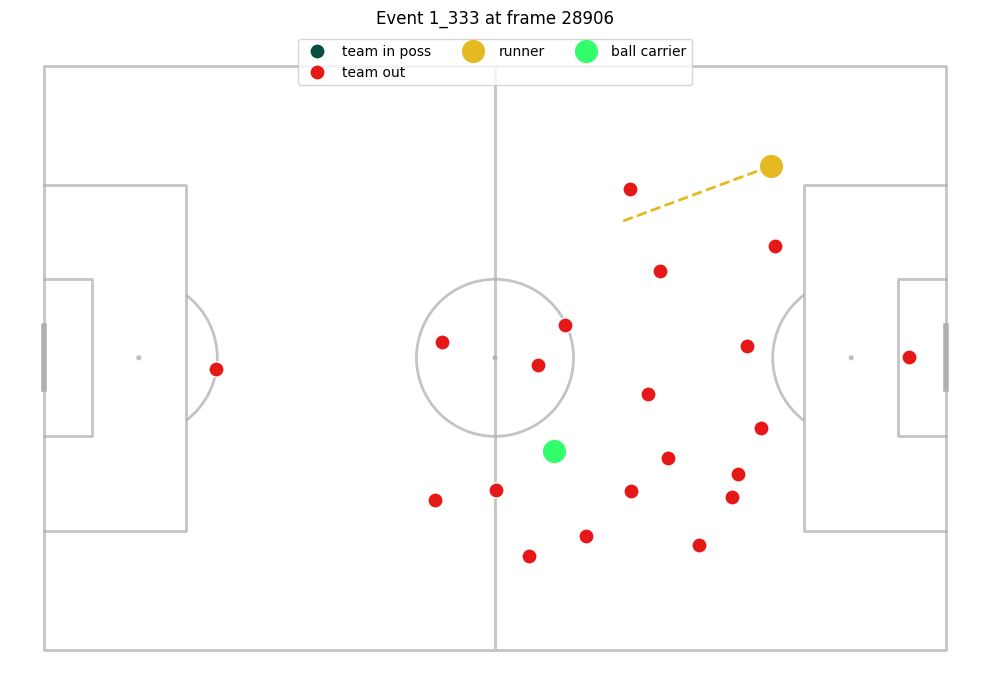

In [109]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Choose an event to visualize
viz_event_id = "1_333"  # change to any valid event_id

if viz_event_id in events_df["event_id"].values and not tracking_df.empty:
    ev = events_df[events_df["event_id"] == viz_event_id].iloc[0]
    frame_for_merge = int(ev["frame_end"])
    merged = tracking_df[tracking_df["frame"] == frame_for_merge].copy()

    if merged.empty:
        print(f"No tracking rows at frame {frame_for_merge}; check tracking data")
    else:
        # Flags similar to tutorial
        if "player_id" in merged.columns:
            merged["runner"] = merged["player_id"] == ev.get("player_id")
            merged["ball_carrier"] = merged["player_id"] == ev.get("player_in_possession_id")
        else:
            merged["runner"] = False
            merged["ball_carrier"] = False
        if "team_id" in merged.columns:
            merged["tip"] = merged["team_id"] == ev.get("team_id")
        else:
            merged["tip"] = False

        # Plot
        pitch = Pitch(pitch_type="skillcorner", line_alpha=0.75, pitch_length=105, pitch_width=68)
        fig, ax = pitch.draw(figsize=(10, 7))

        if "x" in merged.columns and "y" in merged.columns:
            possession_team = merged[merged["tip"] == True]
            out_team = merged[merged["tip"] == False]
            ax.scatter(possession_team.get("x", []), possession_team.get("y", []), c="#084D42", s=120, edgecolors="white", linewidths=1.0, label="team in poss")
            ax.scatter(out_team.get("x", []), out_team.get("y", []), c="#E51717", s=120, edgecolors="white", linewidths=1.0, label="team out")

            runner = merged[merged["runner"] == True]
            ax.scatter(runner.get("x", []), runner.get("y", []), c="#E5BA21", s=200, edgecolors="#E5BA21", linewidths=2.5, label="runner")
            if not runner.empty and "x_start" in ev and "y_start" in ev:
                ax.plot([ev.get("x_start"), runner.iloc[0].get("x")], [ev.get("y_start"), runner.iloc[0].get("y")], color="#E5BA21", ls="--", lw=2)

            ball_carrier = merged[merged["ball_carrier"] == True]
            ax.scatter(ball_carrier.get("x", []), ball_carrier.get("y", []), c="#32FE6B", s=200, edgecolors="#32FE6B", linewidths=2.5, label="ball carrier")

        ax.set_title(f"Event {viz_event_id} at frame {frame_for_merge}")
        ax.legend(loc="upper center", ncol=3)
        plt.show()
else:
    if tracking_df.empty:
        print("Tracking data not loaded; check tracking_file/URL")
    else:
        print(f"event_id {viz_event_id} not found; pick another")

